In [1]:
# Standard library
import os
import json
import math
from pathlib import Path
from datetime import datetime

# Third-party libraries
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFilter
from tqdm.auto import tqdm
from IPython.display import display

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# TorchVision
from torchvision import transforms, models


In [2]:
DATASET_ROOT = Path("AI-Cinematographer-Dataset")  # <-- change this

# -----------------------------------------
# Load ALL excel files (no limits here)
# -----------------------------------------
all_dfs = []

for excel_file in DATASET_ROOT.rglob("*.xlsx"):
    if excel_file.name.startswith("~$"):
        continue

    shot_type = excel_file.parent.name

    try:
        df_tmp = pd.read_excel(excel_file, engine="openpyxl")
        df_tmp["shot_type"] = shot_type
        all_dfs.append(df_tmp)

    except Exception as e:
        print(f"❌ Skipping {excel_file}: {e}")

df = pd.concat(all_dfs, ignore_index=True)

# -----------------------------------------
# Visualization uses ALL data
# -----------------------------------------
summary_df = (
    df.groupby("shot_type")
    .size()
    .reset_index(name="total_shots")
    .sort_values("total_shots", ascending=False)
)

plt.figure()
plt.barh(summary_df["shot_type"], summary_df["total_shots"])
plt.xlabel("Total Shots")
plt.ylabel("Shot Type")
plt.title("Distribution of Shot Types (All Data)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


ValueError: No objects to concatenate

In [6]:
# Count duplicates
row, col = df.shape
dup = df.duplicated(subset="shot_id").sum()
usable = row - dup

print(f"Total shots = {row}")
print(f"Duplicate shots = {dup}")
print(f"Usable shots (unique) = {usable}")

# Drop duplicates
df_dup = df.drop_duplicates(subset="shot_id", keep="first")
row2, col2 = df_dup.shape
print(f"Rows after removing duplicates = {row2}")

# Filter by one aspect ratio
filter_condition = df_dup['image_aspect_ratio_cinema'] == '16:9'
df_169 = df_dup[filter_condition]  # store filtered DataFrame separately
row3, col3 = df_169.shape
print(f"Final usable shots with 16:9 aspect ratio = {row3}")

Total shots = 26026
Duplicate shots = 4213
Usable shots (unique) = 21813
Rows after removing duplicates = 21813
Final usable shots with 16:9 aspect ratio = 3592


In [7]:
DEFAULT_PER_CLASS = 300

# Filter control
ENABLE_FILTER = True
FILTER_COLUMN = "image_aspect_ratio_cinema"        # <-- change
FILTER_VALUE = "16:9"         # <-- change

# Global duplicate control
DROP_DUPLICATES = True
DUPLICATE_SUBSET = None        # None = full row, or ["video_id", "frame_id"]

# Sampling
SHUFFLE_WITHIN_CLASS = True
RANDOM_SEED = 42

# -----------------------------------------
# 1) FILTER per shot_type (report only)
# -----------------------------------------

filtered_frames = []
report = {}

for shot_type, g in df.groupby("shot_type", sort=False):
    original = len(g)

    if ENABLE_FILTER:
        g = g[g[FILTER_COLUMN] == FILTER_VALUE]

    filtered_out = original - len(g)

    report[shot_type] = {
        "original": original,
        "filtered_out": filtered_out,
        "duplicates_dropped": 0,  # filled later
    }

    filtered_frames.append(g)

# Combine AFTER filtering only
filtered_df = pd.concat(filtered_frames, ignore_index=True)

# -----------------------------------------
# 2) GLOBAL duplicate removal (BEFORE merging)
# -----------------------------------------

if DROP_DUPLICATES:
    before = filtered_df.copy()

    filtered_df = filtered_df.drop_duplicates(
        subset=DUPLICATE_SUBSET,
        keep="first"
    )

    # Count dropped duplicates per shot_type
    dropped = before.merge(filtered_df, how="left", indicator=True)
    dropped = dropped[dropped["_merge"] == "left_only"]

    dup_counts = dropped.groupby("shot_type").size().to_dict()

    for k, v in dup_counts.items():
        report[k]["duplicates_dropped"] = v

# -----------------------------------------
# 3) Apply per-class limit
# -----------------------------------------

parts = []

for shot_type, g in filtered_df.groupby("shot_type", sort=False):
    if SHUFFLE_WITHIN_CLASS:
        g = g.sample(frac=1, random_state=RANDOM_SEED)

    parts.append(g.head(DEFAULT_PER_CLASS))

# Final controlled dataset
df = pd.concat(parts, ignore_index=True)

# -----------------------------------------
# 4) Minimal report output
# -----------------------------------------

report_df = (
    pd.DataFrame.from_dict(report, orient="index")
    .reset_index()
    .rename(columns={"index": "shot_type"})
)

print("\n📊 FILTER & GLOBAL DUPLICATE REPORT")
print(report_df)



📊 FILTER & GLOBAL DUPLICATE REPORT
            shot_type  original  filtered_out  duplicates_dropped
0                high      2021          1706                   0
1              Insert      4351          3580                   0
2            Aerial 2      2160          1862                   0
3            Two Shot      2339          1978                   0
4   Over The Shoulder       396           396                   0
5          Group Shot      1852          1551                   0
6   Establishing Shot      4373          3743                   0
7       Clean Single2      1620          1319                   0
8         Dutch Angle      4392          3506                   0
9           Overhead5       342           288                   0
10         Three Shot      1964          1674                   0
11          Low Angle       216           171                   0


In [5]:
# Count duplicates
row, col = df.shape
dup = df.duplicated(subset="shot_id").sum()
usable = row - dup

print(f"Total shots = {row}")
print(f"Duplicate shots = {dup}")
print(f"Usable shots (unique) = {usable}")

# Drop duplicates
df_dup = df.drop_duplicates(subset="shot_id", keep="first")
row2, col2 = df_dup.shape
print(f"Rows after removing duplicates = {row2}")

# Filter by one aspect ratio
filter_condition = df_dup['image_aspect_ratio_cinema'] == '16:9'
df = df_dup[filter_condition]  # store filtered DataFrame separately
row3, col3 = df.shape
print(f"Final usable shots with 16:9 aspect ratio = {row3}")

min_h = 1080
df = df[df["image_height"] >= min_h]
row4, col4 = df.shape
print(f"Rows after removing smaller than a minimum height = {row4}")

Total shots = 2787
Duplicate shots = 351
Usable shots (unique) = 2436
Rows after removing duplicates = 2436
Final usable shots with 16:9 aspect ratio = 2436
Rows after removing smaller than a minimum height = 2170


In [6]:
#df = df.head(50)   # first 5 rows

In [7]:
#raise SystemExit("Cell disabled")

# ============================================================
# FINAL PIPELINE:
# 1) Resize FIRST (uniform scaling) -> TEMP save
# 2) Load TEMP image -> apply ALL transforms
# 3) Export to OUTPUT_DIR/<shot_id>/...
#
# Outputs per shot_id:
#   original.jpg
#   crop_left.jpg
#   crop_right.jpg
#   crop_top.jpg
#   crop_bottom.jpg
#   crop_left_top.jpg
#   crop_left_bottom.jpg
#   crop_right_top.jpg
#   crop_right_bottom.jpg
#   rotate_plus.jpg
#   rotate_minus.jpg
#   labels.json
#
# Also outputs:
#   OUTPUT_DIR/augmented_metadata.csv
#
# NOTES:
# - Do NOT enforce 16:9: we SKIP images that are not ~16:9
# - Resize uses uniform scaling (no cropping / no stretching for true 16:9)
# - Rotation uses minimal-necessary auto-zoom (center-crop then resize) to avoid black borders.
# ============================================================

import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm


# -----------------------------
# 16:9 check (skip if not)
# -----------------------------
def is_16_9(w: int, h: int, tol: float = 0.01) -> bool:
    if h == 0:
        return False
    return abs((w / h) - (16 / 9)) <= tol


# -----------------------------
# Resize FIRST (uniform scaling)
# -----------------------------
def resize_to_fixed(img: Image.Image, target_w: int, target_h: int) -> Image.Image:
    return img.resize((target_w, target_h), Image.Resampling.LANCZOS)


# -----------------------------
# Strong random controller (biased high)
# -----------------------------
def sample_high(rng: np.random.Generator, alpha: float = 5.0, beta: float = 2.0) -> float:
    # Beta(5,2) skews toward 1.0 => stronger perturbations
    return float(rng.beta(alpha, beta))


# -----------------------------
# Your naming semantics (IMPORTANT):
# These mean "cropped from ..." (not "crop towards ...")
#
# crop_bottom = crop from top  -> keep bottom
# crop_top    = crop from bottom -> keep top
# crop_left   = crop from right -> keep left
# crop_right  = crop from left  -> keep right
#
# corners:
# crop_left_top     = crop from right + bottom -> keep top-left
# crop_left_bottom  = crop from right + top    -> keep bottom-left
# crop_right_top    = crop from left  + bottom -> keep top-right
# crop_right_bottom = crop from left  + top    -> keep bottom-right
# -----------------------------
CROP_KEYS = [
    "crop_bottom",
    "crop_left_bottom",
    "crop_left_top",
    "crop_left",
    "crop_right_bottom",
    "crop_right_top",
    "crop_right",
    "crop_top",
]

# Label suggestions (these are the "fix" directions)
MOVE_LABELS = {
    "crop_left":         {"action": "Move right", "dx": +1, "dy":  0},  # right got removed
    "crop_right":        {"action": "Move left",  "dx": -1, "dy":  0},  # left got removed
    "crop_top":          {"action": "Move down",  "dx":  0, "dy": +1},  # bottom got removed
    "crop_bottom":       {"action": "Move up",    "dx":  0, "dy": -1},  # top got removed

    "crop_left_top":     {"action": "Move diagonally down-right", "dx": +1, "dy": +1},  # right+bottom removed
    "crop_left_bottom":  {"action": "Move diagonally up-right",   "dx": +1, "dy": -1},  # right+top removed
    "crop_right_top":    {"action": "Move diagonally down-left",  "dx": -1, "dy": +1},  # left+bottom removed
    "crop_right_bottom": {"action": "Move diagonally up-left",    "dx": -1, "dy": -1},  # left+top removed
}


# -----------------------------
# Crop transform (window shrink + anchor by your semantics)
# Strength controls "how much is cropped" (window shrink), anchor controls which side/corner is removed.
# Output is resized back to WxH (keeps 16:9 and fixed training size).
# -----------------------------
def apply_directional_crop(
    img: Image.Image,
    key: str,
    strength: float,
    min_crop: float = 0.05,
    max_crop: float = 0.35,
    resize_back: bool = True,
):
    w, h = img.size
    crop_frac = min_crop + strength * (max_crop - min_crop)

    crop_h = max(2, int(h * (1.0 - crop_frac)))
    crop_w = max(2, int(crop_h * (16 / 9)))

    crop_w = min(crop_w, w)
    crop_h = min(crop_h, h)

    max_x = w - crop_w
    max_y = h - crop_h

    # Anchor:
    # x0=0   => keep LEFT (right removed)
    # x0=max => keep RIGHT (left removed)
    # y0=0   => keep TOP  (bottom removed)
    # y0=max => keep BOTTOM (top removed)

    if key in ("crop_left", "crop_left_top", "crop_left_bottom"):
        x0 = 0
    elif key in ("crop_right", "crop_right_top", "crop_right_bottom"):
        x0 = max_x
    else:
        x0 = max_x // 2

    if key in ("crop_top", "crop_left_top", "crop_right_top"):
        y0 = 0
    elif key in ("crop_bottom", "crop_left_bottom", "crop_right_bottom"):
        y0 = max_y
    else:
        y0 = max_y // 2

    x0 = max(0, min(x0, max_x))
    y0 = max(0, min(y0, max_y))

    crop_box = (x0, y0, x0 + crop_w, y0 + crop_h)
    cropped = img.crop(crop_box)

    out = cropped.resize((w, h), Image.Resampling.LANCZOS) if resize_back else cropped

    base = MOVE_LABELS[key]
    label = {
        "transform_key": key,
        "params": {
            "strength": strength,
            "crop_frac": crop_frac,
            "crop_box_xyxy": [int(v) for v in crop_box],
            "resized_back_to": [w, h] if resize_back else [crop_w, crop_h],
        },
        "suggestion": {"action": base["action"], "dx": base["dx"], "dy": base["dy"]},
    }
    return out, label


# -----------------------------
# Rotation with MINIMUM necessary scale to remove borders
#
# Key idea:
# - Rotate (expand=True)
# - Compute the LARGEST centered rectangle (same aspect as original) that fits inside
#   the rotated image content (no black corners).
# - Crop that rectangle and resize back to original WxH.
#
# This produces the minimum zoom-in required for a borderless rotated output.
# -----------------------------
def safe_center_crop_size_for_rotation(w: int, h: int, angle_rad: float, inset_px: int = 0):
    """
    Returns (crop_w, crop_h, scale_factor) where:
      - crop_w/crop_h == w/h (same aspect)
      - crop rectangle is the largest centered rectangle that fits inside rotated content
      - resizing crop->(w,h) yields minimal necessary scaling to avoid black borders

    inset_px is a safety margin (0..3 px) to avoid tiny edge artifacts from rounding/resampling.
    """
    R = w / h
    W = w / 2.0
    H = h / 2.0

    s = abs(np.sin(angle_rad))
    c = abs(np.cos(angle_rad))

    # maximal half-height b constrained by rotated-rectangle inequalities:
    # a = R*b
    # a*c + b*s <= W
    # a*s + b*c <= H
    # => b <= W/(R*c + s), b <= H/(R*s + c)
    denom1 = (R * c + s)
    denom2 = (R * s + c)

    # numeric safety
    denom1 = max(1e-9, denom1)
    denom2 = max(1e-9, denom2)

    b = min(W / denom1, H / denom2)
    a = R * b

    crop_w = 2.0 * a - 2.0 * inset_px
    crop_h = 2.0 * b - 2.0 * inset_px

    # convert to ints while preserving aspect ratio as closely as possible
    crop_w_i = max(2, int(np.floor(crop_w)))
    crop_h_i = max(2, int(np.floor(crop_w_i / R)))

    # if that exceeds allowed height (due to rounding), clamp by height then recompute width
    if crop_h_i > int(np.floor(crop_h)):
        crop_h_i = max(2, int(np.floor(crop_h)))
        crop_w_i = max(2, int(np.floor(crop_h_i * R)))

    crop_w_i = min(crop_w_i, w)
    crop_h_i = min(crop_h_i, h)

    scale_factor = w / crop_w_i if crop_w_i > 0 else 1.0
    return crop_w_i, crop_h_i, float(scale_factor)


def apply_rotate_noblack(img: Image.Image, degrees: float, inset_px: int = 0):
    """
    Applies rotation and then minimal-necessary crop+scale so that:
      - Output has NO black borders
      - Output size equals input size
      - Scaling is minimal (largest safe crop)
    """
    w, h = img.size
    angle_rad = np.deg2rad(degrees)

    # Rotate with expanded canvas
    rot = img.rotate(degrees, resample=Image.Resampling.BICUBIC, expand=True)

    # Compute largest safe crop (same aspect)
    crop_w, crop_h, scale_factor = safe_center_crop_size_for_rotation(
        w=w, h=h, angle_rad=angle_rad, inset_px=inset_px
    )

    rw, rh = rot.size
    cx, cy = rw // 2, rh // 2
    left = int(cx - crop_w // 2)
    top = int(cy - crop_h // 2)

    cropped = rot.crop((left, top, left + crop_w, top + crop_h))
    out = cropped.resize((w, h), Image.Resampling.LANCZOS)

    return out, {
        "degrees_applied": float(degrees),
        "safe_crop_size": [int(crop_w), int(crop_h)],
        "scale_factor_min_needed": float(scale_factor),
        "inset_px": int(inset_px),
    }


# -----------------------------
# Build ALL variants (8 crops + rotate_plus + rotate_minus)
# -----------------------------
def build_all_variants(
    base_img: Image.Image,
    rng: np.random.Generator,
    min_crop: float = 0.05,
    max_crop: float = 0.35,
    include_rotations: bool = True,
    min_rotation_deg: float = 2.0,
    max_rotation_deg: float = 12.0,
    rotation_inset_px: int = 1,
):
    variants = {}

    # 8 crop variants
    for key in CROP_KEYS:
        strength = sample_high(rng)
        out, lab = apply_directional_crop(
            base_img, key=key, strength=strength,
            min_crop=min_crop, max_crop=max_crop,
            resize_back=True
        )
        variants[f"{key}.jpg"] = (out, lab)

    # rotations (+ and -)
    if include_rotations:
        # plus
        s1 = sample_high(rng)
        deg1 = min_rotation_deg + s1 * (max_rotation_deg - min_rotation_deg)
        out_plus, params_plus = apply_rotate_noblack(base_img, degrees=+deg1, inset_px=rotation_inset_px)
        lab_plus = {
            "transform_key": "rotate_plus",
            "params": {"strength": s1, **params_plus},
            "suggestion": {"action": "Rotate", "degrees": -float(deg1)},
        }
        variants["rotate_plus.jpg"] = (out_plus, lab_plus)

        # minus
        s2 = sample_high(rng)
        deg2 = min_rotation_deg + s2 * (max_rotation_deg - min_rotation_deg)
        out_minus, params_minus = apply_rotate_noblack(base_img, degrees=-deg2, inset_px=rotation_inset_px)
        lab_minus = {
            "transform_key": "rotate_minus",
            "params": {"strength": s2, **params_minus},
            "suggestion": {"action": "Rotate", "degrees": +float(deg2)},
        }
        variants["rotate_minus.jpg"] = (out_minus, lab_minus)

    return variants


# -----------------------------
# Main exporter (resize->temp->transform->export)
# -----------------------------
def export_all_augmentations_for_df(
    df: pd.DataFrame,
    output_dir: str,
    target_w: int,
    target_h: int,
    image_root: str | None = None,
    temp_dir: str | None = None,
    cleanup_temp: bool = False,
    seed: int = 42,
    min_crop: float = 0.05,
    max_crop: float = 0.35,
    include_rotations: bool = True,
    min_rotation_deg: float = 2.0,
    max_rotation_deg: float = 12.0,
    rotation_inset_px: int = 1,
    jpeg_quality: int = 95,
) -> pd.DataFrame:
    """
    Requirements: df columns {image_path, shot_id}
    """
    required_cols = {"image_path", "shot_id"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"df missing required columns: {missing}")

    out_root = Path(output_dir)
    out_root.mkdir(parents=True, exist_ok=True)

    # Temp folder for resized images
    if temp_dir is None:
        tmp_root = out_root / "_tmp_resized"
    else:
        tmp_root = Path(temp_dir)
    tmp_root.mkdir(parents=True, exist_ok=True)

    rng = np.random.default_rng(seed)
    rows = []

    for _, r in tqdm(df.iterrows(), total=len(df), desc="Resize -> Temp -> Augment -> Export"):
        rel_path = str(r["image_path"])
        shot_id = str(r["shot_id"])

        src_path = Path(rel_path)
        if image_root is not None:
            src_path = Path(image_root) / src_path

        if not src_path.exists():
            rows.append({"shot_id": shot_id, "orig_image_path": str(src_path),
                         "status": "skipped", "skip_reason": "file_not_found"})
            continue

        try:
            img = Image.open(src_path).convert("RGB")
        except Exception as e:
            rows.append({"shot_id": shot_id, "orig_image_path": str(src_path),
                         "status": "skipped", "skip_reason": f"open_failed: {e}"})
            continue

        w, h = img.size
        if not is_16_9(w, h):
            rows.append({"shot_id": shot_id, "orig_image_path": str(src_path),
                         "status": "skipped", "skip_reason": f"not_16_9 ({w}x{h})"})
            continue

        # 1) Resize FIRST
        img_r = resize_to_fixed(img, target_w=target_w, target_h=target_h)

        # 2) Save resized to TEMP
        tmp_path = tmp_root / f"{shot_id}__resized.jpg"
        img_r.save(tmp_path, quality=jpeg_quality)

        # 3) Reload from TEMP (as you requested)
        base_img = Image.open(tmp_path).convert("RGB")

        # 4) Build all variants from base_img
        variants = build_all_variants(
            base_img=base_img,
            rng=rng,
            min_crop=min_crop,
            max_crop=max_crop,
            include_rotations=include_rotations,
            min_rotation_deg=min_rotation_deg,
            max_rotation_deg=max_rotation_deg,
            rotation_inset_px=rotation_inset_px,
        )

        # 5) Export everything at the end
        shot_dir = out_root / shot_id
        shot_dir.mkdir(parents=True, exist_ok=True)

        original_path = shot_dir / "original.jpg"
        base_img.save(original_path, quality=jpeg_quality)

        labels = {
            "version": "v1",
            "created_at": datetime.utcnow().isoformat() + "Z",
            "shot_id": shot_id,
            "source": {"image_path": str(src_path)},
            "preprocess": {
                "resized_to": [target_w, target_h],
                "temp_resized_path": str(tmp_path),
            },
            "files": {
                "original.jpg": {"role": "original_resized", "width": target_w, "height": target_h}
            },
        }

        # Save variants
        for fname, (out_img, lab) in variants.items():
            out_path = shot_dir / fname
            out_img.save(out_path, quality=jpeg_quality)

            labels["files"][fname] = {"role": "perturbed", "transform": lab}

            rows.append({
                "shot_id": shot_id,
                "orig_image_path": str(src_path),
                "aug_image_path": str(out_path),
                "label_path": str(shot_dir / "labels.json"),
                "transform_key": lab["transform_key"],
                "status": "ok",
            })

        # Metadata row for original
        rows.append({
            "shot_id": shot_id,
            "orig_image_path": str(src_path),
            "aug_image_path": str(original_path),
            "label_path": str(shot_dir / "labels.json"),
            "transform_key": "original_resized",
            "status": "ok",
        })

        with open(shot_dir / "labels.json", "w", encoding="utf-8") as f:
            json.dump(labels, f, ensure_ascii=False, indent=2)

        # Optional cleanup of per-image temp file
        if cleanup_temp:
            try:
                tmp_path.unlink(missing_ok=True)
            except Exception:
                pass

    out_df = pd.DataFrame(rows)
    out_df.to_csv(out_root / "augmented_metadata.csv", index=False)

    # Optional cleanup of temp folder if empty
    if cleanup_temp:
        try:
            if not any(tmp_root.iterdir()):
                tmp_root.rmdir()
        except Exception:
            pass

    return out_df


In [8]:
#raise SystemExit("Cell disabled")

# =========================
# USAGE (separate cell)
# =========================
# df must be loaded and contain columns:
#   df["image_path"], df["shot_id"]

OUTPUT_DIR = "perturbed_dataset"      # <-- change
TARGET_W, TARGET_H = 1920, 1080      # <-- change (16:9)
IMAGE_ROOT = None                   # <-- set if df["image_path"] is relative
TEMP_DIR = None                     # <-- or set "/some/temp/location"

out_df = export_all_augmentations_for_df(
    df=df,
    output_dir=OUTPUT_DIR,
    target_w=TARGET_W,
    target_h=TARGET_H,
    image_root=IMAGE_ROOT,
    temp_dir=TEMP_DIR,
    cleanup_temp=False,             # set True if you want temp files deleted after export

    # Crop strength limits (controller)
    min_crop=0.05,
    max_crop=0.35,

    # Rotations
    include_rotations=True,
    min_rotation_deg=2.0,
    max_rotation_deg=12.0,

    # Rotation border removal:
    # inset_px=1 is a good practical default to prevent tiny edge artifacts.
    rotation_inset_px=1,

    seed=42,
    jpeg_quality=95
)

display(out_df.head(20))
print("Saved:", str(Path(OUTPUT_DIR) / "augmented_metadata.csv"))
print("Temp resized folder:", str(Path(OUTPUT_DIR) / "_tmp_resized") if TEMP_DIR is None else TEMP_DIR)


Resize -> Temp -> Augment -> Export:   0%|          | 0/2170 [00:00<?, ?it/s]

/var/folders/wj/fytcb2192vq005wx1j40nd3m0000gn/T/ipykernel_22692/323120240.py:418: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow().isoformat() + "Z",


,shot_id,orig_image_path,aug_image_path,label_path,transform_key,status,skip_reason
0,TMLJ7S8V,/Users/mahmud/Desktop/ShotDeck Scrapper/AI-Cin...,perturbed_dataset/TMLJ7S8V/crop_bottom.jpg,perturbed_dataset/TMLJ7S8V/labels.json,crop_bottom,ok,NaN
1,TMLJ7S8V,/Users/mahmud/Desktop/ShotDeck Scrapper/AI-Cin...,perturbed_dataset/TMLJ7S8V/crop_left_bottom.jpg,perturbed_dataset/TMLJ7S8V/labels.json,crop_left_bottom,ok,NaN
2,TMLJ7S8V,/Users/mahmud/Desktop/ShotDeck Scrapper/AI-Cin...,perturbed_dataset/TMLJ7S8V/crop_left_top.jpg,perturbed_dataset/TMLJ7S8V/labels.json,crop_left_top,ok,NaN
3,TMLJ7S8V,/Users/mahmud/Desktop/ShotDeck Scrapper/AI-Cin...,perturbed_dataset/TMLJ7S8V/crop_left.jpg,perturbed_dataset/TMLJ7S8V/labels.json,crop_left,ok,NaN
4,TMLJ7S8V,/Users/mahmud/Desktop/ShotDeck Scrapper/AI-Cin...,perturbed_dataset/TMLJ7S8V/crop_right_bottom.jpg,perturbed_dataset/TMLJ7S8V/labels.json,crop_right_bottom,ok,NaN
5,TMLJ7S8V,/Users/mahmud/Desktop/ShotDeck Scrapper/AI-Cin...,perturbed_dataset/TMLJ7S8V/crop_right_top.jpg,perturbed_dataset/TMLJ7S8V/labels.json,crop_right_top,ok,NaN
6,TMLJ7S8V,/Users/mahmud/Desktop/ShotDeck Scrapper/AI-Cin...,perturbed_dataset/TMLJ7S8V/crop_right.jpg,perturbed_dataset/TMLJ7S8V/labels.json,crop_right,ok,NaN
7,TMLJ7S8V,/Users/mahmud/Desktop/ShotDeck Scrapper/AI-Cin...,perturbed_dataset/TMLJ7S8V/crop_top.jpg,perturbed_dataset/TMLJ7S8V/labels.json,crop_top,ok,NaN
8,TMLJ7S8V,/Users/mahmud/Desktop/ShotDeck Scrapper/AI-Cin...,perturbed_dataset/TMLJ7S8V/rotate_plus.jpg,perturbed_dataset/TMLJ7S8V/labels.json,rotate_plus,ok,NaN
9,TMLJ7S8V,/Users/mahmud/Desktop/ShotDeck Scrapper/AI-Cin...,perturbed_dataset/TMLJ7S8V/rotate_minus.jpg,perturbed_dataset/TMLJ7S8V/labels.json,rotate_minus,ok,NaN


Saved: perturbed_dataset/augmented_metadata.csv
Temp resized folder: perturbed_dataset/_tmp_resized


In [2]:
# =========================
# Cell 0 — CONFIG (portable)
# =========================
# (No imports here — assume you already imported everything earlier.)

CONFIG = {
    "DATA_DIR": "perturbed_dataset200",   # <-- change only this

    "SEED": 42,

    "IMAGE_SIZE": (224, 126),        # (W, H)
    "BATCH_SIZE": 64,
    "EPOCHS": 3,

    "LR": 3e-4,
    "WEIGHT_DECAY": 1e-4,

    "MAX_ROT_DEG": 12.0,

    # Loss weights (fixes your KeyError)
    "LAMBDA_ROT": 1.0,
    "LAMBDA_GOOD": 1.0,

    # Rotation sample weighting
    "ROT_WEIGHT_ACTIVE": 1.0,
    "ROT_WEIGHT_INACTIVE": 0.10,

    # Inference thresholds
    "GOOD_THRESH": 0.60,
    "MOVE_CONF_THRESH": 0.55,
    "ROT_DEG_THRESH": 1.0,

    "CKPT_DIR": None,  # None -> DATA_DIR/_checkpoints
}

# Safe defaults (prevents KeyError if keys are missing)
CONFIG.setdefault("LAMBDA_ROT", 1.0)
CONFIG.setdefault("LAMBDA_GOOD", 1.0)

np.random.seed(CONFIG["SEED"])
torch.manual_seed(CONFIG["SEED"])
CONFIG


{'DATA_DIR': 'perturbed_dataset200',
 'SEED': 42,
 'IMAGE_SIZE': (224, 126),
 'BATCH_SIZE': 64,
 'EPOCHS': 3,
 'LR': 0.0003,
 'WEIGHT_DECAY': 0.0001,
 'MAX_ROT_DEG': 12.0,
 'LAMBDA_ROT': 1.0,
 'LAMBDA_GOOD': 1.0,
 'ROT_WEIGHT_ACTIVE': 1.0,
 'ROT_WEIGHT_INACTIVE': 0.1,
 'GOOD_THRESH': 0.6,
 'MOVE_CONF_THRESH': 0.55,
 'ROT_DEG_THRESH': 1.0,
 'CKPT_DIR': None}

In [3]:
# ==========================================================
# Cell 1 — Shot-level split (folder is the unit) + manifest
# ORIGINAL => GOOD (no move, 0°)
# Perturbed => BAD
# ==========================================================

DIR_TO_CLASS = {
    ( +1,  0): 0, ( -1,  0): 1, (  0, +1): 2, (  0, -1): 3,
    ( +1, +1): 4, ( +1, -1): 5, ( -1, +1): 6, ( -1, -1): 7,
}
NO_MOVE_CLASS = 8

CLASS_TO_TEXT = [
    "Move right", "Move left", "Move down", "Move up",
    "Move down-right", "Move up-right", "Move down-left", "Move up-left",
    "No move"
]

def build_shot_index(data_dir: str) -> pd.DataFrame:
    data_dir = Path(data_dir)
    rows = []
    for shot_dir in data_dir.iterdir():
        if not shot_dir.is_dir():
            continue
        if shot_dir.name.startswith("_tmp") or shot_dir.name.startswith("_checkpoints"):
            continue
        label_path = shot_dir / "labels.json"
        if not label_path.exists():
            continue
        rows.append({"shot_id": shot_dir.name, "shot_dir": str(shot_dir), "label_path": str(label_path)})
    return pd.DataFrame(rows)

def split_shots(df_shots: pd.DataFrame, seed: int = 42, train=0.8, val=0.1, test=0.1) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    shot_ids = df_shots["shot_id"].unique()
    rng.shuffle(shot_ids)

    n = len(shot_ids)
    n_train = int(n * train)
    n_val = int(n * val)

    train_ids = set(shot_ids[:n_train])
    val_ids   = set(shot_ids[n_train:n_train+n_val])

    def assign(sid):
        if sid in train_ids: return "train"
        if sid in val_ids:   return "val"
        return "test"

    out = df_shots.copy()
    out["split"] = out["shot_id"].map(assign)
    return out

def expand_shots_to_samples(df_shots_split: pd.DataFrame) -> pd.DataFrame:
    samples = []

    for _, row in df_shots_split.iterrows():
        shot_id = row["shot_id"]
        split = row["split"]
        shot_dir = Path(row["shot_dir"])

        with open(shot_dir / "labels.json", "r", encoding="utf-8") as f:
            labels = json.load(f)

        files = labels.get("files", {})

        for fname, info in files.items():
            img_path = shot_dir / fname
            if not img_path.exists():
                continue

            # ORIGINAL => GOOD
            if fname == "original.jpg":
                samples.append({
                    "shot_id": shot_id,
                    "split": split,
                    "image_path": str(img_path),
                    "transform_key": "original",
                    "move_class": NO_MOVE_CLASS,
                    "rot_deg_target": 0.0,
                    "move_active": 0,
                    "rot_active": 0,
                    "rot_weight": CONFIG["ROT_WEIGHT_INACTIVE"],
                    "is_good": 1,
                })
                continue

            transform = (info or {}).get("transform", {}) or {}
            tkey = str(transform.get("transform_key", "unknown"))
            suggestion = transform.get("suggestion", {}) or {}

            # CROP => BAD (move active)
            if tkey.startswith("crop_"):
                dx = int(suggestion.get("dx"))
                dy = int(suggestion.get("dy"))
                move_class = DIR_TO_CLASS[(dx, dy)]
                samples.append({
                    "shot_id": shot_id,
                    "split": split,
                    "image_path": str(img_path),
                    "transform_key": tkey,
                    "move_class": move_class,
                    "rot_deg_target": 0.0,
                    "move_active": 1,
                    "rot_active": 0,
                    "rot_weight": CONFIG["ROT_WEIGHT_INACTIVE"],
                    "is_good": 0,
                })
                continue

            # ROTATE => BAD (rot active)
            if tkey in ("rotate_plus", "rotate_minus"):
                deg = float(suggestion.get("degrees", 0.0) or 0.0)
                samples.append({
                    "shot_id": shot_id,
                    "split": split,
                    "image_path": str(img_path),
                    "transform_key": tkey,
                    "move_class": NO_MOVE_CLASS,
                    "rot_deg_target": deg,
                    "move_active": 0,
                    "rot_active": 1,
                    "rot_weight": CONFIG["ROT_WEIGHT_ACTIVE"],
                    "is_good": 0,
                })
                continue

    return pd.DataFrame(samples)

df_shots = build_shot_index(CONFIG["DATA_DIR"])
df_shots = split_shots(df_shots, seed=CONFIG["SEED"])
manifest = expand_shots_to_samples(df_shots)

# Must be 0 overlap
train_ids = set(df_shots[df_shots["split"]=="train"]["shot_id"])
val_ids   = set(df_shots[df_shots["split"]=="val"]["shot_id"])
test_ids  = set(df_shots[df_shots["split"]=="test"]["shot_id"])
print("shot overlap train∩val:", len(train_ids & val_ids))
print("shot overlap train∩test:", len(train_ids & test_ids))
print("shot overlap val∩test:", len(val_ids & test_ids))

print("Unique shots:", len(df_shots))
display(df_shots["split"].value_counts())
print("Total samples (images):", len(manifest))
display(manifest["transform_key"].value_counts())


shot overlap train∩val: 0
shot overlap train∩test: 0
shot overlap val∩test: 0
Unique shots: 1884


split
train    1507
test      189
val       188
Name: count, dtype: int64

Total samples (images): 20724


transform_key
original             1884
crop_bottom          1884
crop_left_bottom     1884
crop_left_top        1884
crop_left            1884
crop_right_bottom    1884
crop_right_top       1884
crop_right           1884
crop_top             1884
rotate_plus          1884
rotate_minus         1884
Name: count, dtype: int64

In [4]:
# =========================
# Cell N0 — Sanity checks + experiment knobs
# =========================

assert "manifest" in globals(), "Run your Cell 1 first (it must create `manifest`)."
assert "CONFIG" in globals(), "Run your Cell 0 first (CONFIG must exist)."

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---- knobs ----
EXPERIMENT_EPOCHS = 3         # <-- increase later (start small)
EXP_BATCH_SIZE = CONFIG["BATCH_SIZE"]
USE_FEATURES = False           # True -> requires manifest['feature_path'] + npz features
USE_XY = False                 # True -> adds x,y coordinate channels
HEAD_DROPOUT = 0.0             # try 0.1 if you overfit badly

in_ch = 3 + (3 if USE_FEATURES else 0) + (2 if USE_XY else 0)
print("in_ch:", in_ch, "| USE_FEATURES:", USE_FEATURES, "| USE_XY:", USE_XY)

# checkpoints folder for these experiments
CKPT_DIR_MODELS = Path(CONFIG["DATA_DIR"]) / "_checkpoints_models"
CKPT_DIR_MODELS.mkdir(parents=True, exist_ok=True)
print("CKPT_DIR_MODELS:", CKPT_DIR_MODELS)


Device: mps
in_ch: 3 | USE_FEATURES: False | USE_XY: False
CKPT_DIR_MODELS: perturbed_dataset200/_checkpoints_models


In [5]:
# =========================
# Cell N1 — Dataset (guarded): RGB + optional features + optional XY
# =========================

if "CineComposeDatasetOptionalFeatures" not in globals():

    class CineComposeDatasetOptionalFeatures(Dataset):
        def __init__(self, df: pd.DataFrame, image_size=(224,126), max_rot_deg=12.0, use_features=False, use_xy=False):
            self.df = df.reset_index(drop=True)
            self.max_rot_deg = float(max_rot_deg)
            self.use_features = bool(use_features)
            self.use_xy = bool(use_xy)

            W, H = image_size
            self.W, self.H = W, H

            self.tf_rgb = transforms.Compose([
                transforms.Resize((H, W)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]),
            ])

            if self.use_xy:
                xs = torch.linspace(-1.0, 1.0, W).view(1, 1, W).repeat(1, H, 1)
                ys = torch.linspace(-1.0, 1.0, H).view(1, H, 1).repeat(1, 1, W)
                self.xy = torch.cat([xs, ys], dim=0)  # [2,H,W]
            else:
                self.xy = None

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx: int):
            r = self.df.iloc[idx]
            img = Image.open(r["image_path"]).convert("RGB")
            x_rgb = self.tf_rgb(img)  # [3,H,W]
            x = x_rgb

            if self.use_features:
                fpath = r.get("feature_path", None)
                if fpath is None or (not Path(str(fpath)).exists()):
                    raise FileNotFoundError(f"Missing feature file for {r['image_path']} -> {fpath}")

                npz = np.load(str(fpath))
                edges = torch.from_numpy(npz["edges"]).float().unsqueeze(0)  # [1,H,W]
                mag   = torch.from_numpy(npz["mag"]).float().unsqueeze(0)
                sym   = torch.from_numpy(npz["sym"]).float().unsqueeze(0)
                x_feat = torch.cat([edges, mag, sym], dim=0)  # [3,H,W]
                x = torch.cat([x, x_feat], dim=0)             # [6,H,W]

            if self.use_xy:
                x = torch.cat([x, self.xy], dim=0)            # +2 channels

            move_class = int(r["move_class"])
            rot_deg = float(r["rot_deg_target"])
            rot_target = rot_deg / float(self.max_rot_deg)

            return {
                "image": x,
                "move_class": torch.tensor(move_class, dtype=torch.long),
                "rot_target": torch.tensor(rot_target, dtype=torch.float32),
                "rot_weight": torch.tensor(float(r["rot_weight"]), dtype=torch.float32),
                "move_active": torch.tensor(int(r["move_active"]), dtype=torch.float32),
                "rot_active": torch.tensor(int(r["rot_active"]), dtype=torch.float32),
                "is_good": torch.tensor(float(r["is_good"]), dtype=torch.float32),
            }

print("✅ Dataset class ready:", "CineComposeDatasetOptionalFeatures" in globals())


✅ Dataset class ready: True


In [6]:
# =========================
# Cell N2 — Backbones factory (5 non-ResNet + ResNet18/34)
# =========================

def _replace_conv(conv: nn.Conv2d, in_ch: int) -> nn.Conv2d:
    new_conv = nn.Conv2d(
        in_ch, conv.out_channels,
        kernel_size=conv.kernel_size,
        stride=conv.stride,
        padding=conv.padding,
        dilation=conv.dilation,
        groups=1,
        bias=(conv.bias is not None),
        padding_mode=conv.padding_mode
    )
    with torch.no_grad():
        if conv.weight.shape[1] == 3 and in_ch >= 3:
            new_conv.weight[:, :3].copy_(conv.weight)
            if in_ch > 3:
                mean_w = conv.weight.mean(dim=1, keepdim=True)
                new_conv.weight[:, 3:].copy_(mean_w.repeat(1, in_ch - 3, 1, 1))
        else:
            nn.init.kaiming_normal_(new_conv.weight, mode="fan_out", nonlinearity="relu")
        if new_conv.bias is not None:
            nn.init.zeros_(new_conv.bias)
    return new_conv


def make_backbone(backbone_name: str, in_ch: int = 3, pretrained: bool = True):
    name = backbone_name.lower()

    # ---- ResNets ----
    if name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        m = models.resnet18(weights=weights)
        if in_ch != 3:
            m.conv1 = _replace_conv(m.conv1, in_ch)
        feat_dim = m.fc.in_features
        m.fc = nn.Identity()
        return m, feat_dim, (lambda x: m(x))

    if name == "resnet34":
        weights = models.ResNet34_Weights.DEFAULT if pretrained else None
        m = models.resnet34(weights=weights)
        if in_ch != 3:
            m.conv1 = _replace_conv(m.conv1, in_ch)
        feat_dim = m.fc.in_features
        m.fc = nn.Identity()
        return m, feat_dim, (lambda x: m(x))

    # ---- Non-ResNet ----
    if name == "mobilenet_v3_small":
        weights = models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        m = models.mobilenet_v3_small(weights=weights)
        if in_ch != 3:
            m.features[0][0] = _replace_conv(m.features[0][0], in_ch)
        feat_dim = m.classifier[0].in_features
        m.classifier = nn.Identity()
        return m, feat_dim, (lambda x: m(x))

    if name == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        m = models.efficientnet_b0(weights=weights)
        if in_ch != 3:
            m.features[0][0] = _replace_conv(m.features[0][0], in_ch)
        feat_dim = m.classifier[1].in_features
        m.classifier = nn.Identity()
        return m, feat_dim, (lambda x: m(x))

    if name == "densenet121":
        weights = models.DenseNet121_Weights.DEFAULT if pretrained else None
        m = models.densenet121(weights=weights)
        if in_ch != 3:
            m.features.conv0 = _replace_conv(m.features.conv0, in_ch)
        feat_dim = m.classifier.in_features
        m.classifier = nn.Identity()
        return m, feat_dim, (lambda x: m(x))

    if name == "convnext_tiny":
        weights = models.ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None
        m = models.convnext_tiny(weights=weights)
        if in_ch != 3:
            m.features[0][0] = _replace_conv(m.features[0][0], in_ch)
        feat_dim = m.classifier[2].in_features
        m.classifier[2] = nn.Identity()  # keep norm+flatten
        return m, feat_dim, (lambda x: m(x))  # [B, C]

    if name == "vit_b_16":
        weights = models.ViT_B_16_Weights.DEFAULT if pretrained else None
        m = models.vit_b_16(weights=weights)
        if in_ch != 3:
            m.conv_proj = _replace_conv(m.conv_proj, in_ch)
        feat_dim = m.heads.head.in_features
        m.heads = nn.Identity()
        return m, feat_dim, (lambda x: m(x))

    raise ValueError(
        f"Unknown backbone_name: {backbone_name}. "
        f"Choose: resnet18, resnet34, mobilenet_v3_small, efficientnet_b0, densenet121, convnext_tiny, vit_b_16"
    )


In [7]:
# =========================
# Cell N3 — Multi-head wrapper + train/eval for experiments (self-contained)
# =========================

class CineComposeMultiHead(nn.Module):
    def __init__(self, backbone_name: str, in_ch: int = 3, pretrained: bool = True, head_dropout: float = 0.0):
        super().__init__()
        self.backbone, feat_dim, self._feat_fwd = make_backbone(backbone_name, in_ch=in_ch, pretrained=pretrained)

        if head_dropout and head_dropout > 0:
            self.move_head = nn.Sequential(nn.Dropout(head_dropout), nn.Linear(feat_dim, 9))
            self.rot_head  = nn.Sequential(nn.Dropout(head_dropout), nn.Linear(feat_dim, 1))
            self.good_head = nn.Sequential(nn.Dropout(head_dropout), nn.Linear(feat_dim, 1))
        else:
            self.move_head = nn.Linear(feat_dim, 9)
            self.rot_head  = nn.Linear(feat_dim, 1)
            self.good_head = nn.Linear(feat_dim, 1)

    def forward(self, x):
        feat = self._feat_fwd(x)
        move_logits = self.move_head(feat)
        rot_pred = self.rot_head(feat).squeeze(1)
        good_logit = self.good_head(feat).squeeze(1)
        return move_logits, rot_pred, good_logit


# ---- losses (with pos_weight for good/bad imbalance) ----
LAMBDA_ROT  = float(CONFIG.get("LAMBDA_ROT", 1.0))
LAMBDA_GOOD = float(CONFIG.get("LAMBDA_GOOD", 1.0))

train_good = float((manifest[manifest["split"]=="train"]["is_good"] == 1).sum())
train_bad  = float((manifest[manifest["split"]=="train"]["is_good"] == 0).sum())
pos_weight = torch.tensor([train_bad / max(train_good, 1.0)], dtype=torch.float32).to(device)

_ce = nn.CrossEntropyLoss()
_huber_none = nn.SmoothL1Loss(beta=0.1, reduction="none")
_bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def _rotation_loss_weighted(rot_pred, rot_target, rot_weight):
    err = _huber_none(rot_pred, rot_target)   # [B]
    denom = rot_weight.sum().clamp_min(1e-6)
    return (err * rot_weight).sum() / denom


def train_one_epoch_exp(model, loader, optimizer, epoch=1):
    model.train()
    total_loss = 0.0
    move_correct = 0
    move_count = 0
    rot_abs_err = 0.0
    rot_count = 0
    good_correct = 0
    good_count = 0

    pbar = tqdm(loader, desc=f"Train {epoch:02d}", leave=True)
    for batch in pbar:
        x = batch["image"].to(device)
        move_class = batch["move_class"].to(device)

        rot_target = batch["rot_target"].to(device)
        rot_weight = batch["rot_weight"].to(device)

        is_good = batch["is_good"].to(device)
        move_active = batch["move_active"].to(device)
        rot_active = batch["rot_active"].to(device)

        optimizer.zero_grad(set_to_none=True)
        move_logits, rot_pred, good_logit = model(x)

        loss_move = _ce(move_logits, move_class)
        loss_rot  = _rotation_loss_weighted(rot_pred, rot_target, rot_weight)
        loss_good = _bce(good_logit, is_good)

        loss = loss_move + LAMBDA_ROT * loss_rot + LAMBDA_GOOD * loss_good
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += float(loss.item())

        mv_idx = (move_active > 0.5)
        if mv_idx.any():
            preds = move_logits[mv_idx].argmax(dim=1)
            move_correct += (preds == move_class[mv_idx]).sum().item()
            move_count += mv_idx.sum().item()

        rt_idx = (rot_active > 0.5)
        if rt_idx.any():
            rot_abs_err += (rot_pred[rt_idx] - rot_target[rt_idx]).abs().sum().item()
            rot_count += rt_idx.sum().item()

        good_pred = (torch.sigmoid(good_logit) >= 0.5).float()
        good_correct += (good_pred == is_good).sum().item()
        good_count += is_good.numel()

        pbar.set_postfix({
            "loss": f"{(total_loss/max(1,pbar.n+1)):.3f}",
            "move_acc(crop)": f"{(move_correct/max(1,move_count)):.3f}",
            "rot_MAE(deg)": f"{((rot_abs_err/max(1,rot_count))*CONFIG['MAX_ROT_DEG']):.2f}",
            "good_acc": f"{(good_correct/max(1,good_count)):.3f}",
        })

    return {
        "loss": total_loss / max(1, len(loader)),
        "move_acc_crop": move_correct / max(1, move_count),
        "rot_mae_deg": (rot_abs_err / max(1, rot_count)) * CONFIG["MAX_ROT_DEG"],
        "good_acc": good_correct / max(1, good_count),
    }


@torch.no_grad()
def evaluate_exp(model, loader):
    model.eval()
    total_loss = 0.0
    move_correct = 0
    move_count = 0
    rot_abs_err = 0.0
    rot_count = 0
    good_correct = 0
    good_count = 0

    pbar = tqdm(loader, desc="Val", leave=True)
    for batch in pbar:
        x = batch["image"].to(device)
        move_class = batch["move_class"].to(device)

        rot_target = batch["rot_target"].to(device)
        rot_weight = batch["rot_weight"].to(device)

        is_good = batch["is_good"].to(device)
        move_active = batch["move_active"].to(device)
        rot_active = batch["rot_active"].to(device)

        move_logits, rot_pred, good_logit = model(x)

        loss_move = _ce(move_logits, move_class)
        loss_rot  = _rotation_loss_weighted(rot_pred, rot_target, rot_weight)
        loss_good = _bce(good_logit, is_good)
        loss = loss_move + LAMBDA_ROT * loss_rot + LAMBDA_GOOD * loss_good
        total_loss += float(loss.item())

        mv_idx = (move_active > 0.5)
        if mv_idx.any():
            preds = move_logits[mv_idx].argmax(dim=1)
            move_correct += (preds == move_class[mv_idx]).sum().item()
            move_count += mv_idx.sum().item()

        rt_idx = (rot_active > 0.5)
        if rt_idx.any():
            rot_abs_err += (rot_pred[rt_idx] - rot_target[rt_idx]).abs().sum().item()
            rot_count += rt_idx.sum().item()

        good_pred = (torch.sigmoid(good_logit) >= 0.5).float()
        good_correct += (good_pred == is_good).sum().item()
        good_count += is_good.numel()

        pbar.set_postfix({
            "loss": f"{(total_loss/max(1,pbar.n+1)):.3f}",
            "move_acc(crop)": f"{(move_correct/max(1,move_count)):.3f}",
            "rot_MAE(deg)": f"{((rot_abs_err/max(1,rot_count))*CONFIG['MAX_ROT_DEG']):.2f}",
            "good_acc": f"{(good_correct/max(1,good_count)):.3f}",
        })

    return {
        "loss": total_loss / max(1, len(loader)),
        "move_acc_crop": move_correct / max(1, move_count),
        "rot_mae_deg": (rot_abs_err / max(1, rot_count)) * CONFIG["MAX_ROT_DEG"],
        "good_acc": good_correct / max(1, good_count),
    }


In [8]:
# =========================
# Cell N4 — Train all models + save best + record histories
# =========================

# If features are requested, ensure feature_path exists and files exist
if USE_FEATURES:
    assert "feature_path" in manifest.columns, "USE_FEATURES=True but manifest['feature_path'] not found. Run feature precompute cell first."
    missing = (~manifest["feature_path"].map(lambda p: Path(str(p)).exists())).sum()
    if missing > 0:
        raise FileNotFoundError(f"{missing} feature files missing. Re-run feature precompute.")

# loaders (shared across experiments for fair compare)
train_df = manifest[manifest["split"]=="train"].copy()
val_df   = manifest[manifest["split"]=="val"].copy()
test_df  = manifest[manifest["split"]=="test"].copy()

train_ds = CineComposeDatasetOptionalFeatures(train_df, image_size=CONFIG["IMAGE_SIZE"], max_rot_deg=CONFIG["MAX_ROT_DEG"],
                                              use_features=USE_FEATURES, use_xy=USE_XY)
val_ds   = CineComposeDatasetOptionalFeatures(val_df,   image_size=CONFIG["IMAGE_SIZE"], max_rot_deg=CONFIG["MAX_ROT_DEG"],
                                              use_features=USE_FEATURES, use_xy=USE_XY)

train_loader_exp = DataLoader(train_ds, batch_size=EXP_BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader_exp   = DataLoader(val_ds,   batch_size=EXP_BATCH_SIZE, shuffle=False, num_workers=0)

print("Batches/epoch:", len(train_loader_exp))

EXPERIMENTS = [
    dict(name="ResNet18",         backbone="resnet18"),
    dict(name="ResNet34",         backbone="resnet34"),
    dict(name="MobileNetV3Small", backbone="mobilenet_v3_small"),
    dict(name="EfficientNetB0",   backbone="efficientnet_b0"),
    dict(name="ConvNeXtTiny",     backbone="convnext_tiny"),
    dict(name="ViT_B_16",         backbone="vit_b_16"),
]

multi_histories = {}   # model_name -> history dict

for exp in EXPERIMENTS:
    name = exp["name"]
    backbone = exp["backbone"]
    best_path = CKPT_DIR_MODELS / f"best_{name}.pt"

    model_m = CineComposeMultiHead(backbone_name=backbone, in_ch=in_ch, pretrained=True, head_dropout=HEAD_DROPOUT).to(device)
    optimizer_m = optim.AdamW(model_m.parameters(), lr=CONFIG["LR"], weight_decay=CONFIG["WEIGHT_DECAY"])

    hist = {
        "epoch": [],
        "train_loss": [], "val_loss": [],
        "train_move_acc": [], "val_move_acc": [],
        "train_rot_mae": [], "val_rot_mae": [],
        "train_good_acc": [], "val_good_acc": [],
    }

    best_val = float("inf")

    print("\n" + "="*75)
    print(f"MODEL: {name} | backbone={backbone} | in_ch={in_ch}")
    print("Saving best to:", best_path)

    for ep in range(1, EXPERIMENT_EPOCHS + 1):
        tr = train_one_epoch_exp(model_m, train_loader_exp, optimizer_m, epoch=ep)
        va = evaluate_exp(model_m, val_loader_exp)

        hist["epoch"].append(ep)
        hist["train_loss"].append(tr["loss"]);              hist["val_loss"].append(va["loss"])
        hist["train_move_acc"].append(tr["move_acc_crop"]); hist["val_move_acc"].append(va["move_acc_crop"])
        hist["train_rot_mae"].append(tr["rot_mae_deg"]);    hist["val_rot_mae"].append(va["rot_mae_deg"])
        hist["train_good_acc"].append(tr["good_acc"]);      hist["val_good_acc"].append(va["good_acc"])

        print(
            f"{name} | Epoch {ep:02d}/{EXPERIMENT_EPOCHS} | "
            f"train loss {tr['loss']:.4f} move_acc {tr['move_acc_crop']:.3f} rot_MAE {tr['rot_mae_deg']:.2f}° good_acc {tr['good_acc']:.3f} || "
            f"val loss {va['loss']:.4f} move_acc {va['move_acc_crop']:.3f} rot_MAE {va['rot_mae_deg']:.2f}° good_acc {va['good_acc']:.3f}"
        )

        if va["loss"] < best_val:
            best_val = va["loss"]
            torch.save({"model_state_dict": model_m.state_dict(), "config": CONFIG, "exp": exp, "in_ch": in_ch}, best_path)
            print("✅ Saved best:", best_path)

    multi_histories[name] = hist

print("\n✅ Done. Models trained:", list(multi_histories.keys()))


Batches/epoch: 260

MODEL: ResNet18 | backbone=resnet18 | in_ch=3
Saving best to: perturbed_dataset\_checkpoints_models\best_ResNet18.pt


Val: 100%|████████| 33/33 [01:40<00:00,  3.06s/it, loss=3.252, move_acc(crop)=0.249, rot_MAE(deg)=5.82, good_acc=0.766]


ResNet18 | Epoch 01/3 | train loss 3.4201 move_acc 0.220 rot_MAE 6.97° good_acc 0.620 || val loss 3.2518 move_acc 0.249 rot_MAE 5.82° good_acc 0.766
✅ Saved best: perturbed_dataset\_checkpoints_models\best_ResNet18.pt


Val: 100%|████████| 33/33 [01:01<00:00,  1.88s/it, loss=3.393, move_acc(crop)=0.272, rot_MAE(deg)=5.29, good_acc=0.738]


ResNet18 | Epoch 02/3 | train loss 2.6525 move_acc 0.387 rot_MAE 5.19° good_acc 0.747 || val loss 3.3934 move_acc 0.272 rot_MAE 5.29° good_acc 0.738


...

ConvNeXtTiny | Epoch 03/3 | train loss 1.8898 move_acc 0.559 rot_MAE 4.26° good_acc 0.845 || val loss 4.3804 move_acc 0.364 rot_MAE 4.62° good_acc 0.900
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\tahsi/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth


100%|███████████████████████████████████████████████████████████████████████████████| 330M/330M [00:54<00:00, 6.36MB/s]



MODEL: ViT_B_16 | backbone=vit_b_16 | in_ch=3
Saving best to: perturbed_dataset\_checkpoints_models\best_ViT_B_16.pt


Train 01:   0%|                                                                                | 0/260 [00:01<?, ?it/s]


AssertionError: Wrong image height! Expected 224 but got 126!

In [21]:
# ==========================================================
# Cell Y — Evaluation function (3-head) for val/test
# (Run before evaluate(model, test_loader))
# ==========================================================

_ce = nn.CrossEntropyLoss()
_huber_none = nn.SmoothL1Loss(beta=0.1, reduction="none")

@torch.no_grad()
def _rotation_loss_weighted(rot_pred, rot_target, rot_weight):
    err = _huber_none(rot_pred, rot_target)   # [B]
    denom = rot_weight.sum().clamp_min(1e-6)
    return (err * rot_weight).sum() / denom

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    move_correct = 0
    move_count = 0
    rot_abs_err = 0.0
    rot_count = 0
    good_correct = 0
    good_count = 0

    # Use unweighted BCE at eval-time (training used pos_weight, but eval should be fair)
    _bce_eval = nn.BCEWithLogitsLoss()

    for batch in tqdm(loader, desc="Test", leave=True):
        x = batch["image"].to(device)
        move_class = batch["move_class"].to(device)

        rot_target = batch["rot_target"].to(device)
        rot_weight = batch["rot_weight"].to(device)

        is_good = batch["is_good"].to(device)

        move_active = batch["move_active"].to(device)
        rot_active = batch["rot_active"].to(device)

        move_logits, rot_pred, good_logit = model(x)

        loss_move = _ce(move_logits, move_class)
        loss_rot  = _rotation_loss_weighted(rot_pred, rot_target, rot_weight)
        loss_good = _bce_eval(good_logit, is_good)

        # Use CONFIG lambdas if present (safe defaults)
        lam_rot  = float(CONFIG.get("LAMBDA_ROT", 1.0))
        lam_good = float(CONFIG.get("LAMBDA_GOOD", 1.0))

        loss = loss_move + lam_rot * loss_rot + lam_good * loss_good
        total_loss += loss.item()

        # Move acc on crop-only
        mv_idx = (move_active > 0.5)
        if mv_idx.any():
            preds = move_logits[mv_idx].argmax(dim=1)
            move_correct += (preds == move_class[mv_idx]).sum().item()
            move_count += mv_idx.sum().item()

        # Rotation MAE on rotate-only (convert normalized target to degrees)
        rt_idx = (rot_active > 0.5)
        if rt_idx.any():
            rot_abs_err += (rot_pred[rt_idx] - rot_target[rt_idx]).abs().sum().item()
            rot_count += rt_idx.sum().item()

        # Good/bad accuracy on all
        good_pred = (torch.sigmoid(good_logit) >= 0.5).float()
        good_correct += (good_pred == is_good).sum().item()
        good_count += is_good.numel()

    return {
        "loss": total_loss / max(1, len(loader)),
        "move_acc_crop": move_correct / max(1, move_count),
        "rot_mae_deg": (rot_abs_err / max(1, rot_count)) * float(CONFIG["MAX_ROT_DEG"]),
        "good_acc": good_correct / max(1, good_count),
    }


Checkpoint dir: perturbed_dataset200/_checkpoints_models

------------------------------
Evaluating: best_ConvNeXtTiny.pt | backbone: convnext_tiny


Test:   0%|          | 0/33 [00:00<?, ?it/s]


------------------------------
Evaluating: best_EfficientNetB0.pt | backbone: efficientnet_b0


Test:   0%|          | 0/33 [00:00<?, ?it/s]


------------------------------
Evaluating: best_MobileNetV3Small.pt | backbone: mobilenet_v3_small


...

Test:   0%|          | 0/33 [00:00<?, ?it/s]


------------------------------
Evaluating: best_ResNet34.pt | backbone: resnet34


Test:   0%|          | 0/33 [00:00<?, ?it/s]


========== FINAL TEST LEADERBOARD (sorted by test_loss) ==========


,checkpoint,backbone,test_loss,test_move_acc_crop,test_rot_mae_deg,test_good_acc,ckpt_path
0,best_EfficientNetB0.pt,efficientnet_b0,1.793333,0.456349,4.198252,0.851371,perturbed_dataset200/_checkpoints_models/best_...
1,best_ConvNeXtTiny.pt,convnext_tiny,2.318146,0.333995,4.719999,0.730640,perturbed_dataset200/_checkpoints_models/best_...
2,best_ResNet18.pt,resnet18,2.372951,0.287037,5.221227,0.775854,perturbed_dataset200/_checkpoints_models/best_...
3,best_MobileNetV3Small.pt,mobilenet_v3_small,2.446883,0.290344,4.613504,0.649832,perturbed_dataset200/_checkpoints_models/best_...
4,best_ResNet34.pt,resnet34,2.715930,0.253307,5.639878,0.745551,perturbed_dataset200/_checkpoints_models/best_...


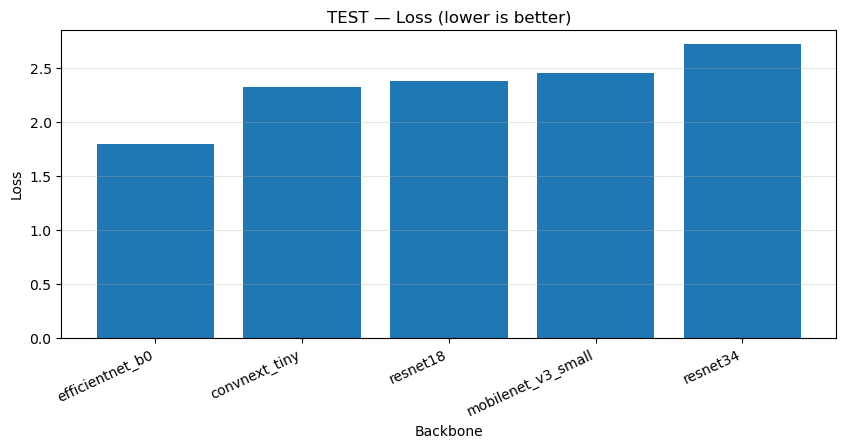

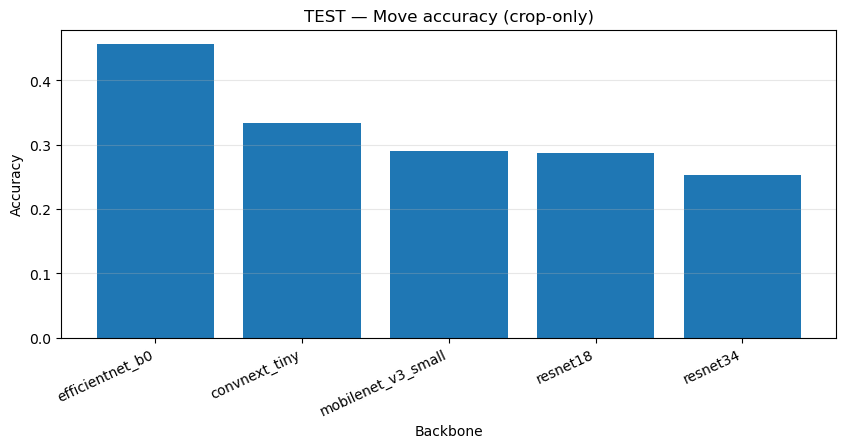

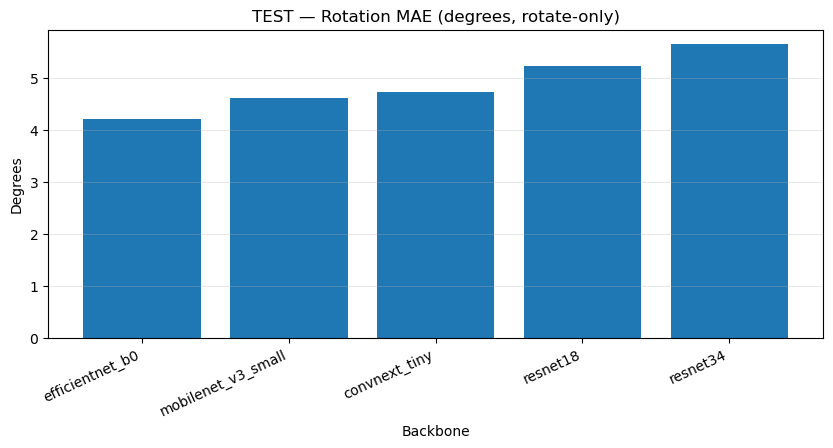

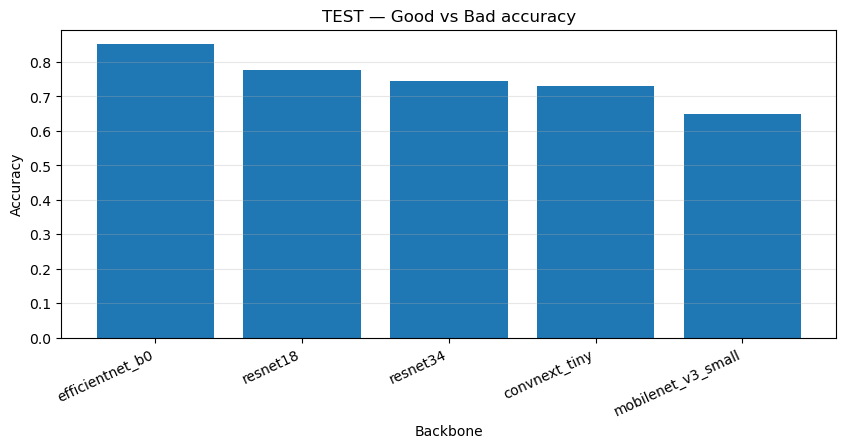

In [20]:
# ==========================================================
# Cell — Evaluate ALL best_* checkpoints on TEST
# ==========================================================

assert "test_loader" in globals(), "test_loader not found. Build test_loader first."
assert "evaluate" in globals(), "evaluate() not found. Run evaluate() cell first."
assert "CineComposeMultiHead" in globals(), "CineComposeMultiHead not found. Run model-definition cell first."
assert "device" in globals(), "device not found. Run device cell first."
assert "CONFIG" in globals(), "CONFIG not found. Run CONFIG cell first."

# ---- checkpoint folder ----
ckpt_dir = Path(CONFIG.get("CKPT_MODELS_DIR", "")) if CONFIG.get("CKPT_MODELS_DIR", "") else (Path(CONFIG["DATA_DIR"]) / "_checkpoints_models")
if not ckpt_dir.exists():
    ckpt_dir = Path("perturbed_dataset") / "_checkpoints_models"

print("Checkpoint dir:", ckpt_dir)
ckpt_paths = sorted(list(ckpt_dir.glob("best_*.pt")))
assert len(ckpt_paths) > 0, f"No best_*.pt found in {ckpt_dir}"

# ---- filename tag -> backbone key ----
def _tag_to_backbone(filename_stem: str) -> str:
    # stem like: best_ResNet18, best_ConvNeXtTiny
    tag = filename_stem.replace("best_", "")
    key = tag.lower().replace(" ", "").replace("_", "").replace("-", "")

    mapping = {
        "resnet18": "resnet18",
        "resnet34": "resnet34",
        "mobilenetv3small": "mobilenet_v3_small",
        "efficientnetb0": "efficientnet_b0",
        "convnexttiny": "convnext_tiny",
        # if you trained more, add here:
        "densenet121": "densenet121",
        "vitb16": "vit_b_16",
    }
    if key not in mapping:
        raise ValueError(f"Unknown checkpoint tag '{tag}'. Add it to mapping in _tag_to_backbone().")
    return mapping[key]

results = []

for p in ckpt_paths:
    ckpt = torch.load(p, map_location=device)

    backbone = None

    # 1) Prefer backbone name saved in ckpt config (if available)
    if isinstance(ckpt, dict) and "config" in ckpt and isinstance(ckpt["config"], dict):
        cfg = ckpt["config"]
        backbone = cfg.get("backbone_name") or cfg.get("BACKBONE") or cfg.get("backbone") or cfg.get("BACKBONE_NAME")

    # 2) Otherwise infer from filename
    if not backbone:
        backbone = _tag_to_backbone(p.stem)

    # Normalize if config used a tag like "ResNet18"
    try:
        backbone = _tag_to_backbone("best_" + str(backbone))
    except Exception:
        pass  # already in correct form like "resnet18"

    print("\n------------------------------")
    print("Evaluating:", p.name, "| backbone:", backbone)

    model = CineComposeMultiHead(backbone_name=backbone, pretrained=False, in_ch=3).to(device)
    model.load_state_dict(ckpt["model_state_dict"], strict=True)
    model.eval()

    tm = evaluate(model, test_loader)

    results.append({
        "checkpoint": p.name,
        "backbone": backbone,
        "test_loss": tm["loss"],
        "test_move_acc_crop": tm["move_acc_crop"],
        "test_rot_mae_deg": tm["rot_mae_deg"],
        "test_good_acc": tm["good_acc"],
        "ckpt_path": str(p),
    })

df_test = pd.DataFrame(results).sort_values("test_loss").reset_index(drop=True)

print("\n========== FINAL TEST LEADERBOARD (sorted by test_loss) ==========")
display(df_test)

# ---- plots ----
def _bar(df, col, title, ylabel, ascending=False):
    tmp = df.sort_values(col, ascending=ascending)
    plt.figure(figsize=(10, 4))
    plt.bar(tmp["backbone"], tmp[col])
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Backbone")
    plt.xticks(rotation=25, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

_bar(df_test, "test_loss", "TEST — Loss (lower is better)", "Loss", ascending=True)
_bar(df_test, "test_move_acc_crop", "TEST — Move accuracy (crop-only)", "Accuracy", ascending=False)
_bar(df_test, "test_rot_mae_deg", "TEST — Rotation MAE (degrees, rotate-only)", "Degrees", ascending=True)
_bar(df_test, "test_good_acc", "TEST — Good vs Bad accuracy", "Accuracy", ascending=False)
